In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("train.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (593994, 13)


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [3]:
df = df.sample(n=50000, random_state=42)

print("Sample shape:", df.shape)

Sample shape: (50000, 13)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 404674 to 291420
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    50000 non-null  int64  
 1   annual_income         50000 non-null  float64
 2   debt_to_income_ratio  50000 non-null  float64
 3   credit_score          50000 non-null  int64  
 4   loan_amount           50000 non-null  float64
 5   interest_rate         50000 non-null  float64
 6   gender                50000 non-null  object 
 7   marital_status        50000 non-null  object 
 8   education_level       50000 non-null  object 
 9   employment_status     50000 non-null  object 
 10  loan_purpose          50000 non-null  object 
 11  grade_subgrade        50000 non-null  object 
 12  loan_paid_back        50000 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 5.3+ MB
None


In [5]:
df.describe(include="all")

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000,50000,50000,50000,50000,50000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,4,5,5,8,30,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Female,Single,Bachelor's,Employed,Debt consolidation,C3,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,25834,24233,23793,37815,27410,4901,NaN
mean,296577.981560,48214.159163,0.120292,680.719060,15051.392464,12.362197,NaN,NaN,NaN,NaN,NaN,NaN,0.797060
std,171556.600751,26873.038142,0.068564,55.369349,6935.358595,2.016958,NaN,NaN,NaN,NaN,NaN,NaN,0.402192
min,2.000000,6026.310000,0.011000,445.000000,514.060000,3.200000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,148484.750000,27982.592500,0.072000,646.000000,10292.782500,11.010000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
50%,295544.500000,46552.490000,0.095000,682.000000,15000.800000,12.380000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
75%,444014.750000,60953.550000,0.156000,719.000000,18869.180000,13.680000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64


In [7]:
print(df["loan_paid_back"].value_counts())
print("\nProportions:")
print(df["loan_paid_back"].value_counts(normalize=True))

loan_paid_back
1.0    39853
0.0    10147
Name: count, dtype: int64

Proportions:
loan_paid_back
1.0    0.79706
0.0    0.20294
Name: proportion, dtype: float64


In [8]:
df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,296577.981560,48214.159163,0.120292,680.719060,15051.392464,12.362197,0.797060
std,171556.600751,26873.038142,0.068564,55.369349,6935.358595,2.016958,0.402192
min,2.000000,6026.310000,0.011000,445.000000,514.060000,3.200000,0.000000
25%,148484.750000,27982.592500,0.072000,646.000000,10292.782500,11.010000,1.000000
50%,295544.500000,46552.490000,0.095000,682.000000,15000.800000,12.380000,1.000000
75%,444014.750000,60953.550000,0.156000,719.000000,18869.180000,13.680000,1.000000
max,593972.000000,380653.890000,0.577000,849.000000,48632.750000,20.450000,1.000000


In [9]:
categorical_cols = [
    "gender",
    "marital_status",
    "education_level",
    "employment_status",
    "loan_purpose",
    "grade_subgrade"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
Female    25834
Male      23858
Other       308
Name: count, dtype: int64

marital_status:
marital_status
Single      24233
Married     23360
Divorced     1789
Widowed       618
Name: count, dtype: int64

education_level:
education_level
Bachelor's     23793
High School    15186
Master's        7828
Other           2282
PhD              911
Name: count, dtype: int64

employment_status:
employment_status
Employed         37815
Unemployed        5242
Self-employed     4452
Retired           1470
Student           1021
Name: count, dtype: int64

loan_purpose:
loan_purpose
Debt consolidation    27410
Other                  5406
Car                    4914
Home                   3671
Education              3123
Business               2912
Medical                1878
Vacation                686
Name: count, dtype: int64

grade_subgrade:
grade_subgrade
C3    4901
C4    4760
C2    4474
C1    4444
C5    4374
D3    3214
D1    3189
D2    2933
D4    2896
D5    2800
B2    1307
B1   

In [10]:
X = df.drop(columns=["loan_paid_back", "id"])
y = df["loan_paid_back"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (50000, 11)
Target: (50000,)


In [11]:
numerical_cols = [
    "annual_income",
    "debt_to_income_ratio",
    "credit_score",
    "loan_amount",
    "interest_rate"
]

categorical_cols = [
    "gender",
    "marital_status",
    "education_level",
    "employment_status",
    "loan_purpose",
    "grade_subgrade"
]

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 11)
Testing data: (10000, 11)


In [16]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [17]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


### Prediction and Accuracy Checking

In [18]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9007


### Confusion Matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1196  833]
 [ 160 7811]]


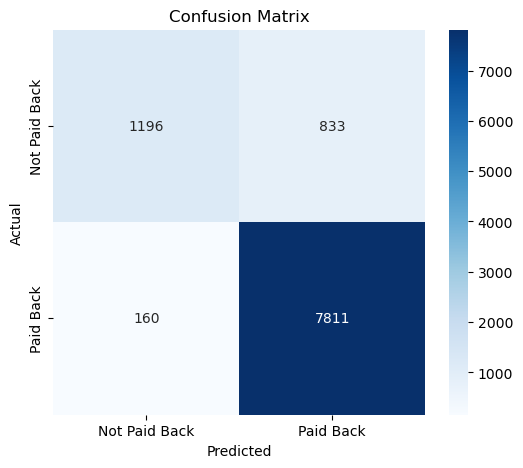

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Paid Back", "Paid Back"],
    yticklabels=["Not Paid Back", "Paid Back"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Classifiaction Report

In [32]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Paid Back", "Paid Back"]
))

               precision    recall  f1-score   support

Not Paid Back       0.88      0.59      0.71      2029
    Paid Back       0.90      0.98      0.94      7971

     accuracy                           0.90     10000
    macro avg       0.89      0.78      0.82     10000
 weighted avg       0.90      0.90      0.89     10000



### Testing with New Applicant

In [23]:
new_applicant = pd.DataFrame({
    "annual_income": [60000],
    "debt_to_income_ratio": [0.15],
    "credit_score": [720],
    "loan_amount": [15000],
    "interest_rate": [10.5],
    "gender": ["Male"],
    "marital_status": ["Married"],
    "education_level": ["Bachelor's"],
    "employment_status": ["Employed"],
    "loan_purpose": ["Home"],
    "grade_subgrade": ["B2"]
})

new_applicant

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,60000,0.15,720,15000,10.5,Male,Married,Bachelor's,Employed,Home,B2


In [29]:
prediction = model.predict(new_applicant)
if prediction[0] == 1:
    print("Loan Prediction: PAID BACK ")
else:
    print("Loan Prediction: NOT PAID BACK ")

Loan Prediction: PAID BACK 


## Importing joblib to Save Our Model

In [25]:
import joblib

In [26]:
joblib.dump(model, "loan_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Loading The Saved Model

In [27]:
loaded_model = joblib.load("loan_prediction_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [30]:
loaded_prediction = loaded_model.predict(new_applicant)

if loaded_prediction[0] == 1:
    print("Loan Prediction: PAID BACK ")
else:
    print("Loan Prediction: NOT PAID BACK ")

Loan Prediction: PAID BACK 
